
# Algorithmes de Prediction Supervisee
**Explication des Indicateurs & Resultats**

Préparé par: Rajae LAOUINI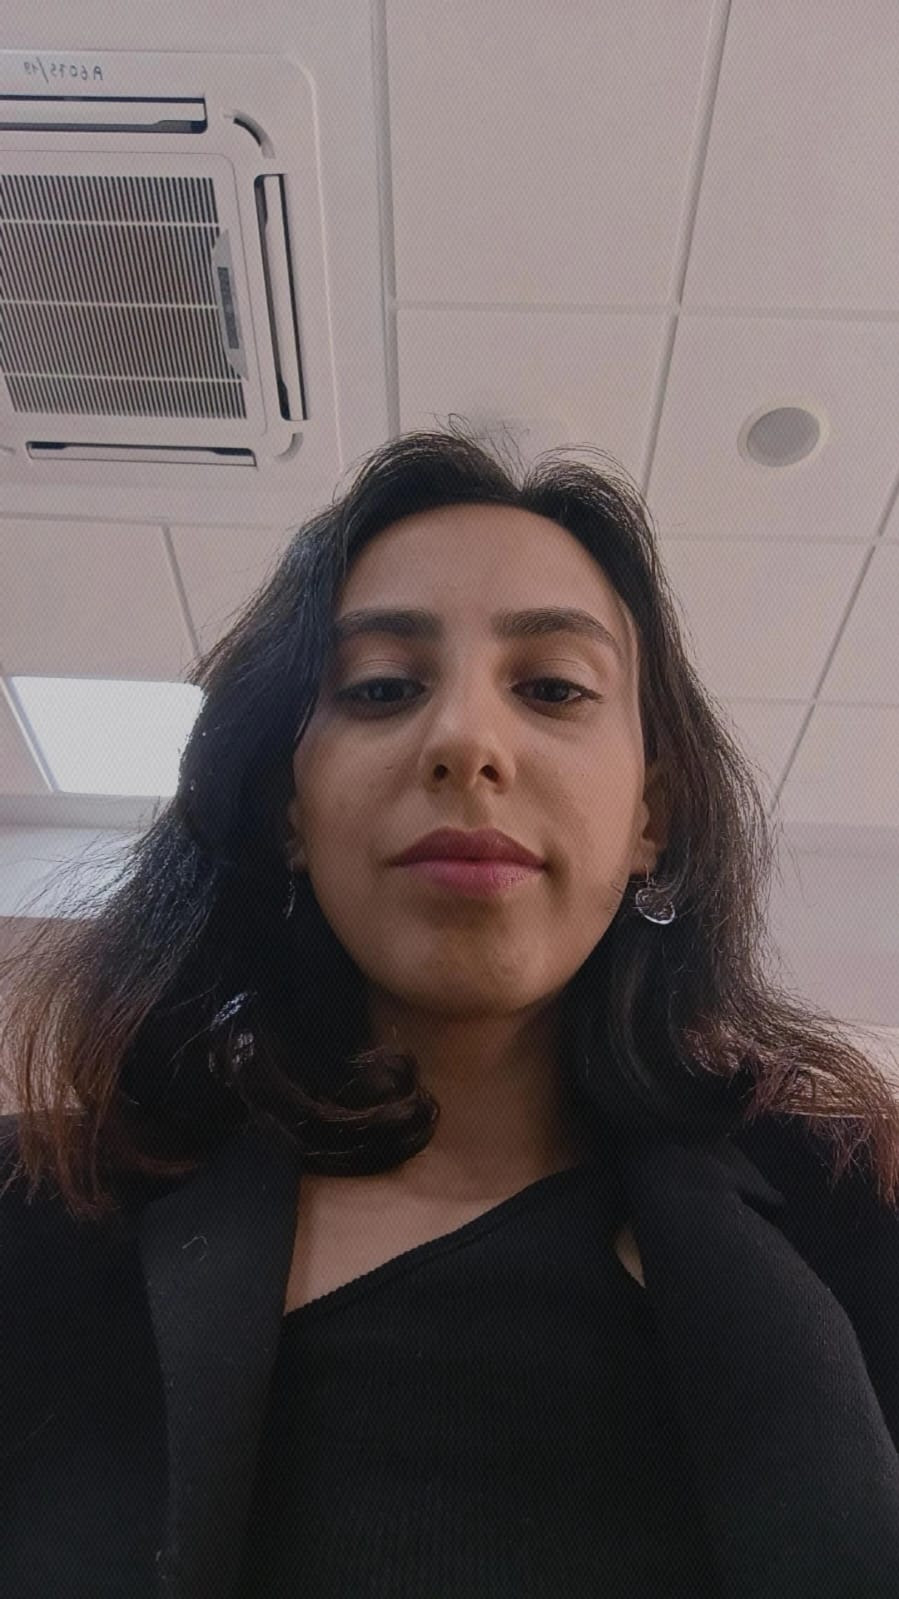
             Salma MOKLAA
             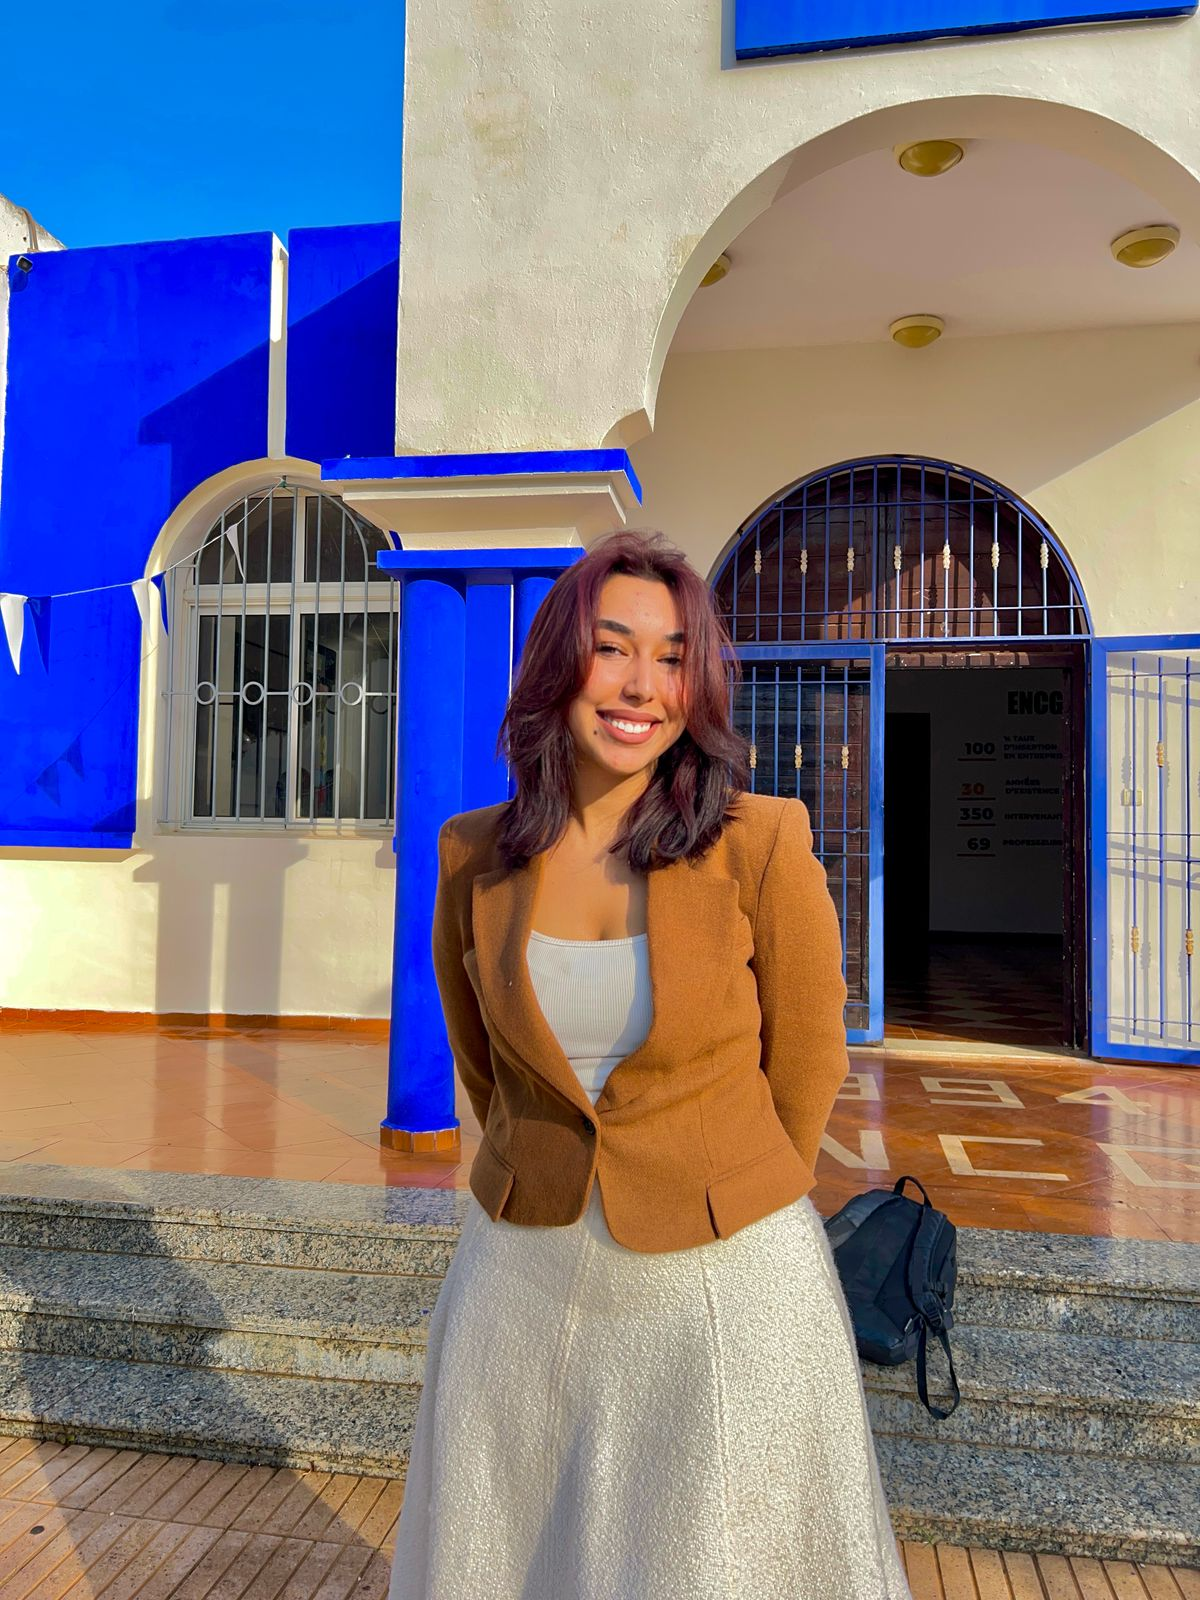

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn import datasets
from sklearn.model_selection import (train_test_split, cross_validate,
                                     GridSearchCV, RandomizedSearchCV,
                                     StratifiedKFold, RepeatedStratifiedKFold,
                                     learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, Binarizer, PolynomialFeatures
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, r2_score, mean_squared_error,
                             brier_score_loss)


**CHARGEMENT DES DATASETS**

In [ ]:
iris       = datasets.load_iris()
breast     = datasets.load_breast_cancer()
wine       = datasets.load_wine()
digits     = datasets.load_digits()
diabetes   = datasets.load_diabetes()
california = datasets.fetch_california_housing()

print("Datasets chargés :")
print(f"  Iris       : {iris.data.shape}")
print(f"  Breast     : {breast.data.shape}")
print(f"  Wine       : {wine.data.shape}")
print(f"  Digits     : {digits.data.shape}")
print(f"  Diabetes   : {diabetes.data.shape}")
print(f"  California : {california.data.shape}")

Datasets chargés :
  Iris       : (150, 4)
  Breast     : (569, 30)
  Wine       : (178, 13)
  Digits     : (1797, 64)
  Diabetes   : (442, 10)
  California : (20640, 8)


SPLITS 80/20

In [ ]:
def split(ds, stratify=True):
    X, y = ds.data, ds.target
    strat = y if stratify else None
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=strat)

X_iris_tr,  X_iris_te,  y_iris_tr,  y_iris_te  = split(iris)
X_bc_tr,    X_bc_te,    y_bc_tr,    y_bc_te    = split(breast)
X_wine_tr,  X_wine_te,  y_wine_tr,  y_wine_te  = split(wine)
X_dig_tr,   X_dig_te,   y_dig_tr,   y_dig_te   = split(digits)
X_diab_tr,  X_diab_te,  y_diab_tr,  y_diab_te  = split(diabetes, stratify=False)
X_cal_tr,   X_cal_te,   y_cal_tr,   y_cal_te   = split(california, stratify=False)

sc4 = StandardScaler()
X_cal_tr_s = sc4.fit_transform(X_cal_tr); X_cal_te_s = sc4.transform(X_cal_te)


Double-cliquez (ou appuyez sur Entrée) pour modifier

sc = StandardScaler()
X_iris_tr_s = sc.fit_transform(X_iris_tr); X_iris_te_s = sc.transform(X_iris_te)

sc2 = StandardScaler()
X_bc_tr_s = sc2.fit_transform(X_bc_tr); X_bc_te_s = sc2.transform(X_bc_te)

sc3 = StandardScaler()
X_diab_tr_s = sc3.fit_transform(X_diab_tr); X_diab_te_s = sc3.transform(X_diab_te)

sc4 = StandardScaler()
X_cal_tr_s = sc4.fit_transform(X_cal_tr); X_cal_te_s = sc4.transform(X_cal_te)



# **SECTION A — CLASSIFICATION**

 1. Régression Logistique

In [ ]:
print("\n═══ 1. Régression Logistique ═══")
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])
lr_pipe.fit(X_iris_tr, y_iris_tr)
pred = lr_pipe.predict(X_iris_te)
print(f"Iris Accuracy : {accuracy_score(y_iris_te, pred):.4f}")
print(classification_report(y_iris_te, pred, target_names=iris.target_names))



═══ 1. Régression Logistique ═══
Iris Accuracy : 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



2. Decision Tree


═══ 2. Decision Tree Classifier ═══
Wine Accuracy : 0.9444


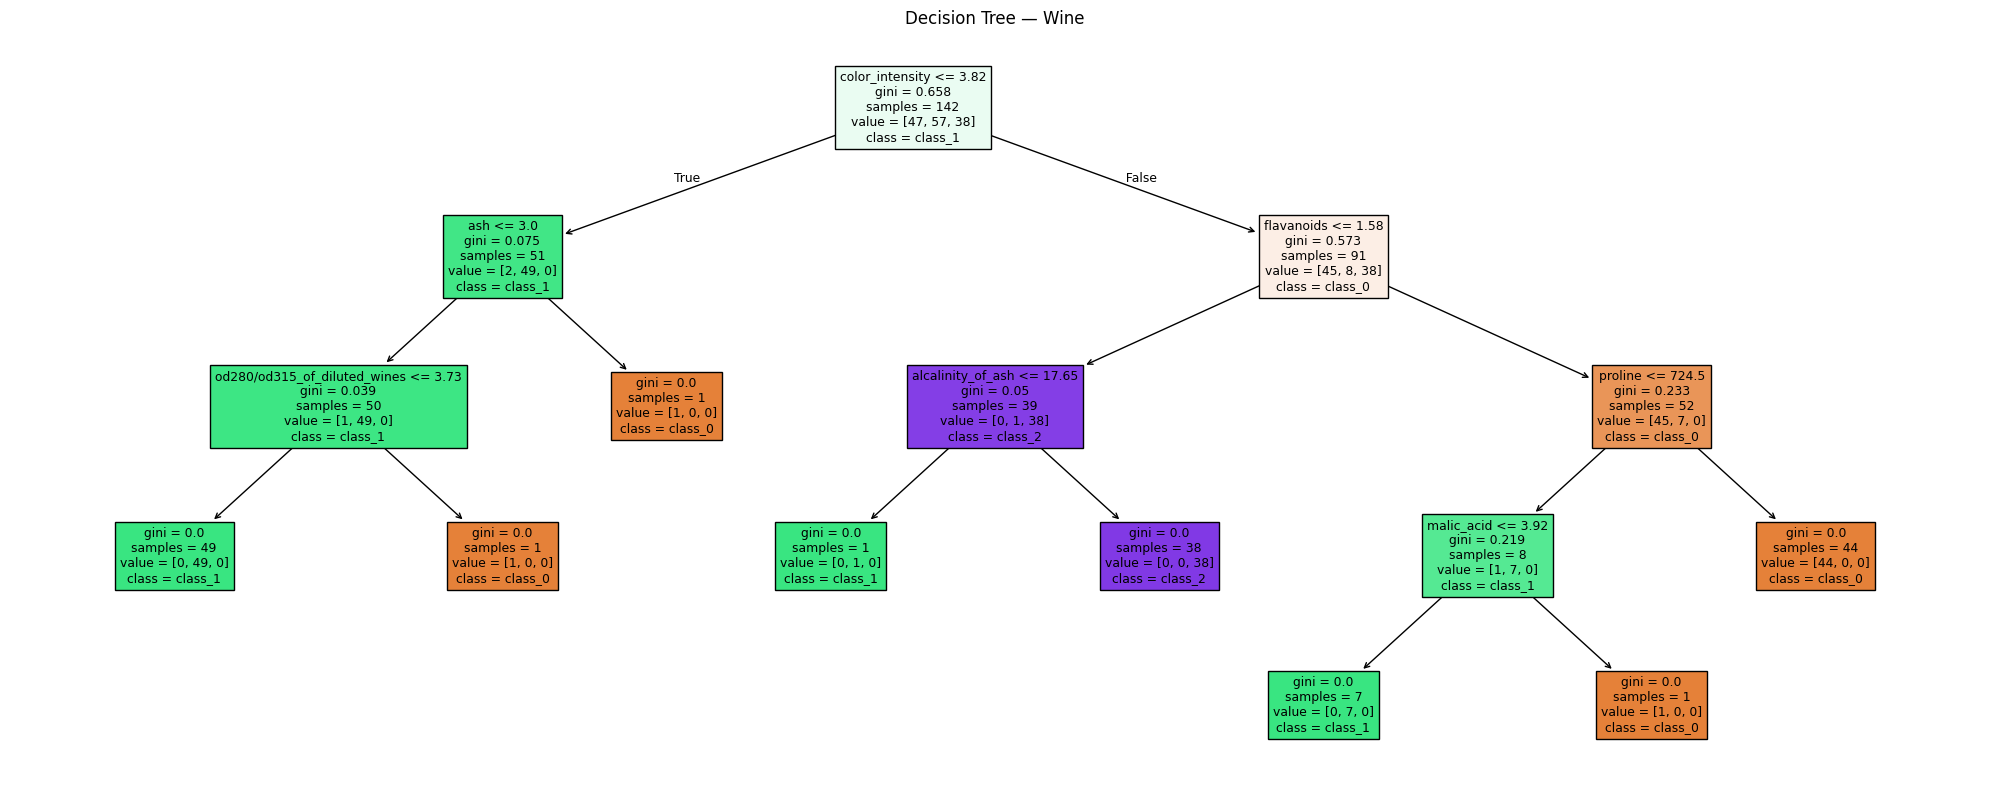

In [ ]:
print("\n═══ 2. Decision Tree Classifier ═══")
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=4, min_samples_split=5, random_state=42)
dt.fit(X_wine_tr, y_wine_tr)
print(f"Wine Accuracy : {accuracy_score(y_wine_te, dt.predict(X_wine_te)):.4f}")

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=wine.feature_names,
          class_names=wine.target_names, filled=True, ax=ax)
plt.title("Decision Tree — Wine")
plt.tight_layout(); plt.show()

**3. Random Forest**


═══ 3. Random Forest Classifier ═══
Iris Accuracy : 0.9000


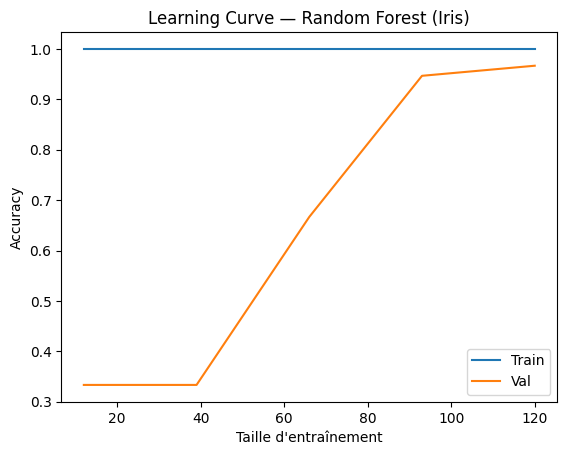

In [ ]:
print("\n═══ 3. Random Forest Classifier ═══")
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_features="sqrt",
                             random_state=42, n_jobs=-1)
rf.fit(X_iris_tr, y_iris_tr)
print(f"Iris Accuracy : {accuracy_score(y_iris_te, rf.predict(X_iris_te)):.4f}")

# Learning curve
train_sz, train_sc, test_sc = learning_curve(rf, iris.data, iris.target, cv=5)
plt.figure()
plt.plot(train_sz, train_sc.mean(1), label="Train")
plt.plot(train_sz, test_sc.mean(1),  label="Val")
plt.xlabel("Taille d'entraînement"); plt.ylabel("Accuracy")
plt.title("Learning Curve — Random Forest (Iris)"); plt.legend(); plt.show()

**4. Gradient Boosting**


═══ 4. Gradient Boosting Classifier ═══
Breast Cancer Accuracy : 0.9561


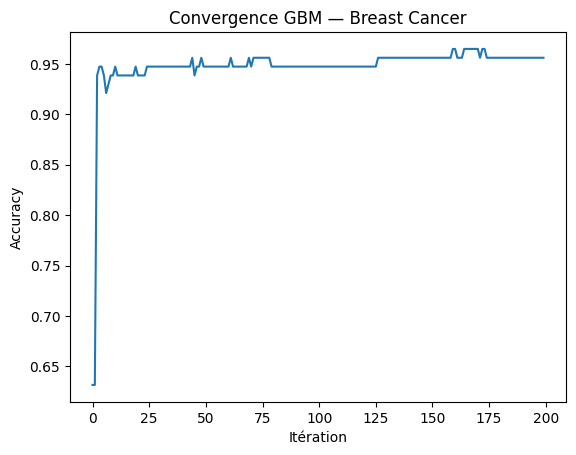

In [ ]:
print("\n═══ 4. Gradient Boosting Classifier ═══")
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=3, subsample=0.8, random_state=42)
gb.fit(X_bc_tr, y_bc_tr)
print(f"Breast Cancer Accuracy : {accuracy_score(y_bc_te, gb.predict(X_bc_te)):.4f}")

staged = [accuracy_score(y_bc_te, p) for p in gb.staged_predict(X_bc_te)]
plt.figure()
plt.plot(staged); plt.xlabel("Itération"); plt.ylabel("Accuracy")
plt.title("Convergence GBM — Breast Cancer"); plt.show()

**5. SVM**

In [ ]:
print("\n═══ 5. SVM (RBF) ═══")
from sklearn.svm import SVC

svm_pipe = Pipeline([
    ("sc",  StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])
svm_pipe.fit(X_iris_tr, y_iris_tr)
print(f"Iris Accuracy : {accuracy_score(y_iris_te, svm_pipe.predict(X_iris_te)):.4f}")

svm_dig = Pipeline([("sc", StandardScaler()),
                    ("svm", SVC(kernel="rbf", C=10, gamma="scale"))])
svm_dig.fit(X_dig_tr, y_dig_tr)
print(f"Digits Accuracy : {accuracy_score(y_dig_te, svm_dig.predict(X_dig_te)):.4f}")


═══ 5. SVM (RBF) ═══
Iris Accuracy : 0.9667
Digits Accuracy : 0.9806


**6. KNN**


═══ 6. K-Nearest Neighbors ═══
Meilleur k=1, Accuracy=0.9667


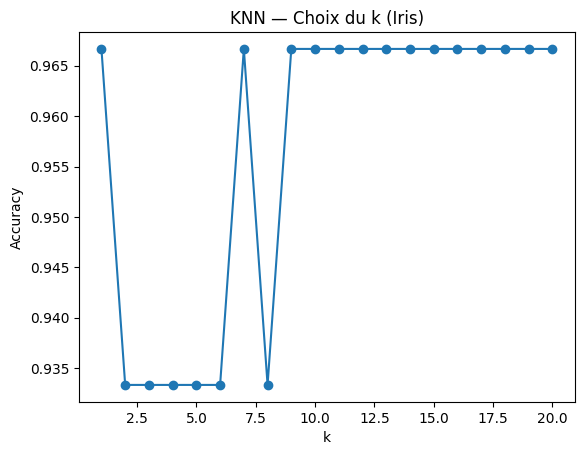

In [ ]:
print("\n═══ 6. K-Nearest Neighbors ═══")
from sklearn.neighbors import KNeighborsClassifier

k_scores = []
for k in range(1, 21):
    knn = Pipeline([("sc", StandardScaler()),
                    ("knn", KNeighborsClassifier(n_neighbors=k))])
    knn.fit(X_iris_tr, y_iris_tr)
    k_scores.append(accuracy_score(y_iris_te, knn.predict(X_iris_te)))

best_k = np.argmax(k_scores) + 1
print(f"Meilleur k={best_k}, Accuracy={max(k_scores):.4f}")
plt.figure()
plt.plot(range(1, 21), k_scores, marker="o")
plt.xlabel("k"); plt.ylabel("Accuracy")
plt.title("KNN — Choix du k (Iris)"); plt.show()


**7. Naive Bayes Gaussien**

In [ ]:
print("\n═══ 7. Naive Bayes (Gaussian) ═══")
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_iris_tr, y_iris_tr)
print(f"Iris Accuracy : {accuracy_score(y_iris_te, gnb.predict(X_iris_te)):.4f}")

gnb_bc = GaussianNB()
gnb_bc.fit(X_bc_tr, y_bc_tr)
print(f"Breast Cancer Accuracy : {accuracy_score(y_bc_te, gnb_bc.predict(X_bc_te)):.4f}")


═══ 7. Naive Bayes (Gaussian) ═══
Iris Accuracy : 0.9667
Breast Cancer Accuracy : 0.9386


**8. AdaBoost**


═══ 8. AdaBoost Classifier ═══
Breast Cancer Accuracy : 0.9561


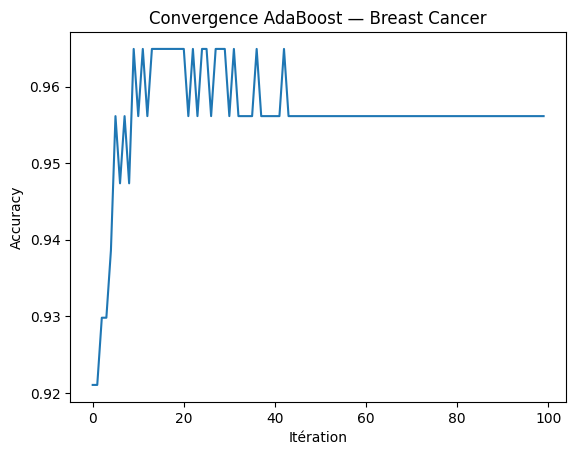

In [ ]:
print("\n═══ 8. AdaBoost Classifier ═══")
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5,
                          algorithm="SAMME", random_state=42)
ada.fit(X_bc_tr, y_bc_tr)
staged_ada = [accuracy_score(y_bc_te, p) for p in ada.staged_predict(X_bc_te)]
print(f"Breast Cancer Accuracy : {staged_ada[-1]:.4f}")
plt.figure()
plt.plot(staged_ada); plt.xlabel("Itération"); plt.ylabel("Accuracy")
plt.title("Convergence AdaBoost — Breast Cancer"); plt.show()

**9. MLP (Neural Network)**


═══ 9. MLP Classifier ═══
Digits Accuracy : 0.9722


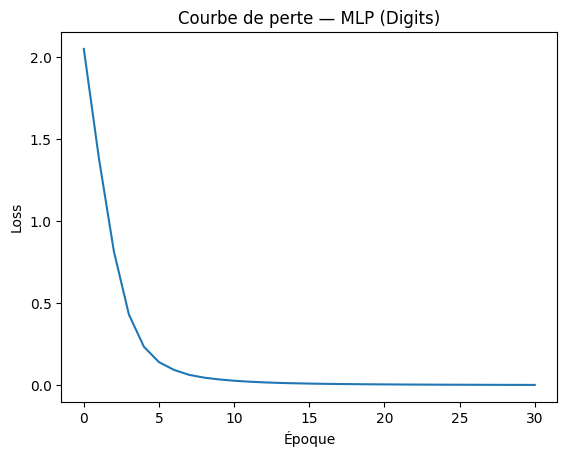

In [ ]:
print("\n═══ 9. MLP Classifier ═══")
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("sc",  StandardScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(256, 128, 64),
                          activation="relu", solver="adam",
                          max_iter=300, early_stopping=True,
                          validation_fraction=0.1, random_state=42))
])
mlp.fit(X_dig_tr, y_dig_tr)
print(f"Digits Accuracy : {accuracy_score(y_dig_te, mlp.predict(X_dig_te)):.4f}")

plt.figure()
plt.plot(mlp["mlp"].loss_curve_)
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.title("Courbe de perte — MLP (Digits)"); plt.show()

**10. Extra Trees**

In [ ]:
print("\n═══ 10. Extra Trees Classifier ═══")
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)
et.fit(X_wine_tr, y_wine_tr)
print(f"Wine Accuracy : {accuracy_score(y_wine_te, et.predict(X_wine_te)):.4f}")



═══ 10. Extra Trees Classifier ═══
Wine Accuracy : 1.0000


**11. LDA**


═══ 11. LDA ═══
Iris Accuracy : 1.0000


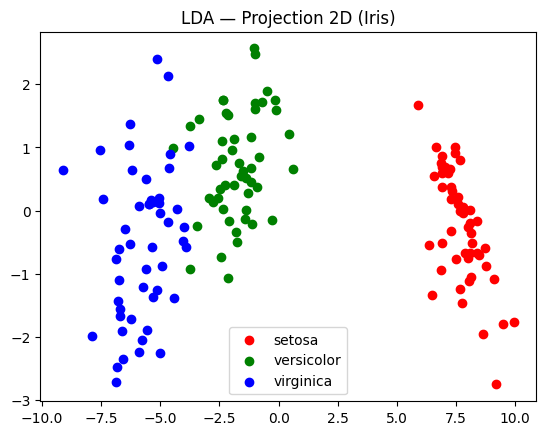

In [ ]:
print("\n═══ 11. LDA ═══")
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_iris_tr, y_iris_tr)
print(f"Iris Accuracy : {accuracy_score(y_iris_te, lda.predict(X_iris_te)):.4f}")

X_2d = lda.transform(iris.data)
plt.figure()
colors = ["red", "green", "blue"]
for i, c in enumerate(colors):
    mask = iris.target == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=c, label=iris.target_names[i])
plt.title("LDA — Projection 2D (Iris)"); plt.legend(); plt.show()

**12. QDA**

In [ ]:
print("\n═══ 12. QDA ═══")
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis(reg_param=0.1)
qda.fit(X_iris_tr, y_iris_tr)
print(f"Iris Accuracy : {accuracy_score(y_iris_te, qda.predict(X_iris_te)):.4f}")


═══ 12. QDA ═══
Iris Accuracy : 0.9667


**13. SGD Classifier**

In [ ]:
print("\n═══ 13. SGD Classifier ═══")
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([
    ("sc",  StandardScaler()),
    ("sgd", SGDClassifier(loss="log_loss", penalty="l2",
                          max_iter=1000, random_state=42))
])
sgd.fit(X_dig_tr, y_dig_tr)
print(f"Digits Accuracy : {accuracy_score(y_dig_te, sgd.predict(X_dig_te)):.4f}")


═══ 13. SGD Classifier ═══
Digits Accuracy : 0.9333


**14. Bagging Classifier**

In [ ]:
print("\n═══ 14. Bagging Classifier ═══")
from sklearn.ensemble import BaggingClassifier

bag = BaggingClassifier(estimator=DecisionTreeClassifier(),
                         n_estimators=100, max_samples=0.8,
                         bootstrap=True, oob_score=True,
                         random_state=42, n_jobs=-1)
bag.fit(X_wine_tr, y_wine_tr)
print(f"Wine Accuracy : {accuracy_score(y_wine_te, bag.predict(X_wine_te)):.4f}")
print(f"OOB Score     : {bag.oob_score_:.4f}")


═══ 14. Bagging Classifier ═══
Wine Accuracy : 1.0000
OOB Score     : 0.9507


**15. Voting Classifier**

In [ ]:
print("\n═══ 15. Voting Classifier ═══")
from sklearn.ensemble import VotingClassifier

knn_pipe = Pipeline([("sc", StandardScaler()),
                     ("knn", KNeighborsClassifier(n_neighbors=5))])
vote = VotingClassifier(
    estimators=[("lr", lr_pipe), ("rf", rf), ("knn", knn_pipe)],
    voting="soft"
)
vote.fit(X_iris_tr, y_iris_tr)
print(f"Iris Accuracy : {accuracy_score(y_iris_te, vote.predict(X_iris_te)):.4f}")


═══ 15. Voting Classifier ═══
Iris Accuracy : 0.9000


**16. Stacking Classifier**

In [ ]:
print("\n═══ 16. Stacking Classifier ═══")
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[("rf", rf), ("gb", gb), ("knn", knn_pipe)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, stack_method="predict_proba"
)
stack.fit(X_bc_tr, y_bc_tr)
print(f"Breast Cancer Accuracy : {accuracy_score(y_bc_te, stack.predict(X_bc_te)):.4f}")


═══ 16. Stacking Classifier ═══
Breast Cancer Accuracy : 0.9561


**17. Gaussian Process Classifier**

In [ ]:
print("\n═══ 17. Gaussian Process Classifier ═══")
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

gpc = GaussianProcessClassifier(kernel=RBF(), random_state=42)
gpc.fit(X_iris_tr_s, y_iris_tr)
print(f"Iris Accuracy : {accuracy_score(y_iris_te, gpc.predict(X_iris_te_s)):.4f}")
print(f"Kernel optimisé : {gpc.kernel_}")


═══ 17. Gaussian Process Classifier ═══
Iris Accuracy : 0.9333
Kernel optimisé : CompoundKernel(0.59, 0.0756, 0.541)


**18. Ridge Classifier**

In [ ]:
print("\n═══ 18. Ridge Classifier ═══")
from sklearn.linear_model import RidgeClassifier, RidgeClassifierCV

rc = Pipeline([("sc", StandardScaler()), ("rc", RidgeClassifier(alpha=1.0))])
rc.fit(X_iris_tr, y_iris_tr)
print(f"Iris Accuracy : {accuracy_score(y_iris_te, rc.predict(X_iris_te)):.4f}")


═══ 18. Ridge Classifier ═══
Iris Accuracy : 0.7667


**19. Naive Bayes Multinomial (texte)**

In [ ]:
print("\n═══ 19. Naive Bayes Multinomial (20 Newsgroups) ═══")
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.datasets import fetch_20newsgroups

cats = ["alt.atheism", "sci.space", "rec.sport.baseball", "comp.graphics"]
news_tr = fetch_20newsgroups(subset="train", categories=cats)
news_te = fetch_20newsgroups(subset="test",  categories=cats)

mnb_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("mnb",   MultinomialNB(alpha=0.1))
])
mnb_pipe.fit(news_tr.data, news_tr.target)
print(f"Newsgroups Accuracy : {accuracy_score(news_te.target, mnb_pipe.predict(news_te.data)):.4f}")



═══ 19. Naive Bayes Multinomial (20 Newsgroups) ═══
Newsgroups Accuracy : 0.9540


**20. Naive Bayes Bernoulli**

In [ ]:
print("\n═══ 20. Naive Bayes Bernoulli ═══")
from sklearn.naive_bayes import BernoulliNB

bnb = Pipeline([
    ("bin", Binarizer(threshold=0.0)),
    ("bnb", BernoulliNB(alpha=1.0))
])
bnb.fit(X_bc_tr_s, y_bc_tr)
print(f"Breast Cancer Accuracy : {accuracy_score(y_bc_te, bnb.predict(X_bc_te_s)):.4f}")


═══ 20. Naive Bayes Bernoulli ═══
Breast Cancer Accuracy : 0.9298


**21 & 22. Perceptron + Passive-Aggressive**

In [ ]:
print("\n═══ 21. Perceptron ═══")
from sklearn.linear_model import Perceptron, PassiveAggressiveClassifier

perc = Pipeline([("sc", StandardScaler()),
                 ("p",  Perceptron(max_iter=1000, eta0=0.1, random_state=42))])
perc.fit(X_iris_tr, y_iris_tr)
print(f"Iris Accuracy : {accuracy_score(y_iris_te, perc.predict(X_iris_te)):.4f}")

print("\n═══ 22. Passive-Aggressive Classifier ═══")
pa = Pipeline([("sc", StandardScaler()),
               ("pa", PassiveAggressiveClassifier(C=1.0, max_iter=1000, random_state=42))])
pa.fit(X_bc_tr, y_bc_tr)
print(f"Breast Cancer Accuracy : {accuracy_score(y_bc_te, pa.predict(X_bc_te)):.4f}")


═══ 21. Perceptron ═══
Iris Accuracy : 0.8667

═══ 22. Passive-Aggressive Classifier ═══
Breast Cancer Accuracy : 0.9912


**23. Calibration**


═══ 23. Calibration de modèle ═══
Brier Score (0=parfait) : 0.0265


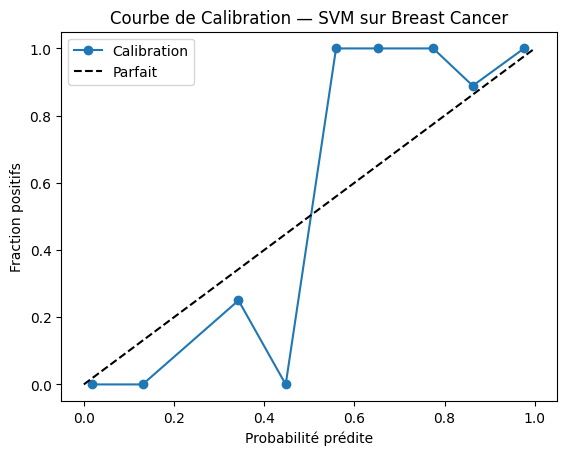

In [ ]:
print("\n═══ 23. Calibration de modèle ═══")
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.svm import SVC

cal_svm = CalibratedClassifierCV(SVC(kernel="rbf"), cv=5, method="sigmoid")
cal_svm.fit(X_bc_tr_s, y_bc_tr)
proba_cal = cal_svm.predict_proba(X_bc_te_s)
brier = brier_score_loss(y_bc_te, proba_cal[:, 1])
print(f"Brier Score (0=parfait) : {brier:.4f}")

frac_pos, mean_pred = calibration_curve(y_bc_te, proba_cal[:, 1], n_bins=10)
plt.figure()
plt.plot(mean_pred, frac_pos, marker="o", label="Calibration")
plt.plot([0,1],[0,1], "k--", label="Parfait")
plt.title("Courbe de Calibration — SVM sur Breast Cancer")
plt.xlabel("Probabilité prédite"); plt.ylabel("Fraction positifs")
plt.legend(); plt.show()


# **SECTION B — RÉGRESSION**

**24. Régression Linéaire (OLS)**

In [ ]:
print("\n═══ 24. Régression Linéaire OLS ═══")
from sklearn.linear_model import LinearRegression

ols = Pipeline([("sc", StandardScaler()), ("lr", LinearRegression())])
ols.fit(X_cal_tr, y_cal_tr)
pred_ols = ols.predict(X_cal_te)
print(f"California R²   : {r2_score(y_cal_te, pred_ols):.4f}")
print(f"California RMSE : {np.sqrt(mean_squared_error(y_cal_te, pred_ols)):.4f}")



═══ 24. Régression Linéaire OLS ═══
California R²   : 0.5758
California RMSE : 0.7456


**25. Ridge / Lasso / ElasticNet**

In [ ]:
print("\n═══ 25. Ridge / Lasso / ElasticNet ═══")
from sklearn.linear_model import Ridge, Lasso, ElasticNet

for name, model in [("Ridge",      Ridge(alpha=1.0)),
                    ("Lasso",      Lasso(alpha=0.1, max_iter=5000)),
                    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5))]:
    pipe = Pipeline([("sc", StandardScaler()), ("m", model)])
    pipe.fit(X_diab_tr, y_diab_tr)
    r2 = r2_score(y_diab_te, pipe.predict(X_diab_te))
    print(f"  {name:12s} R² = {r2:.4f}")


═══ 25. Ridge / Lasso / ElasticNet ═══
  Ridge        R² = 0.4541
  Lasso        R² = 0.4555
  ElasticNet   R² = 0.4590


**26 & 27. DT / RF Regressor**

In [ ]:
print("\n═══ 26–27. Decision Tree & Random Forest Regressor ═══")
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dtr = DecisionTreeRegressor(max_depth=6, random_state=42)
rfr = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)

for name, model in [("DT Regressor", dtr), ("RF Regressor", rfr)]:
    model.fit(X_cal_tr, y_cal_tr)
    r2 = r2_score(y_cal_te, model.predict(X_cal_te))
    print(f"  {name:15s} R² = {r2:.4f}")


═══ 26–27. Decision Tree & Random Forest Regressor ═══
  DT Regressor    R² = 0.6205
  RF Regressor    R² = 0.8051


**28. Gradient Boosting Regressor**


═══ 28. Gradient Boosting Regressor ═══
California R² : 0.8270


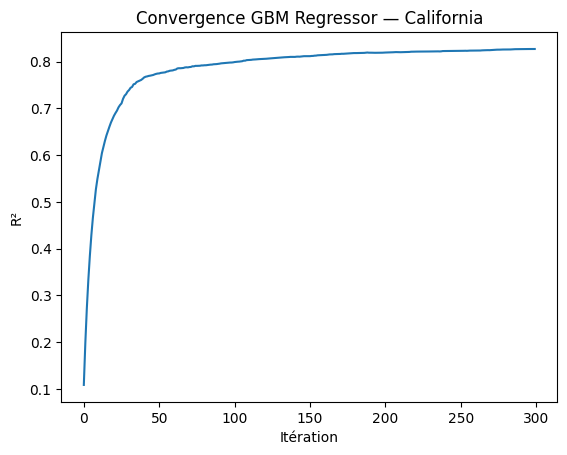

In [ ]:
print("\n═══ 28. Gradient Boosting Regressor ═══")
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1,
                                 max_depth=4, subsample=0.8, random_state=42)
gbr.fit(X_cal_tr, y_cal_tr)
staged_r2 = [r2_score(y_cal_te, p) for p in gbr.staged_predict(X_cal_te)]
print(f"California R² : {staged_r2[-1]:.4f}")
plt.figure()
plt.plot(staged_r2); plt.xlabel("Itération"); plt.ylabel("R²")
plt.title("Convergence GBM Regressor — California"); plt.show()

**29. SVR**

In [ ]:
print("\n═══ 29. SVR ═══")
from sklearn.svm import SVR

svr = Pipeline([("sc", StandardScaler()),
                ("svr", SVR(kernel="rbf", C=100, epsilon=0.1))])
svr.fit(X_diab_tr, y_diab_tr)
print(f"Diabetes R² : {r2_score(y_diab_te, svr.predict(X_diab_te)):.4f}")


═══ 29. SVR ═══
Diabetes R² : 0.5078


**30 KNN Regressor.**

In [ ]:
print("\n═══ 30. KNN Regressor ═══")
from sklearn.neighbors import KNeighborsRegressor

knnr = Pipeline([("sc", StandardScaler()),
                 ("knn", KNeighborsRegressor(n_neighbors=7, weights="distance"))])
knnr.fit(X_cal_tr, y_cal_tr)
print(f"California R² : {r2_score(y_cal_te, knnr.predict(X_cal_te)):.4f}")


═══ 30. KNN Regressor ═══
California R² : 0.6767


**31. MLP Regressor**

In [ ]:
print("\n═══ 31. MLP Regressor ═══")
from sklearn.neural_network import MLPRegressor

mlp_reg = Pipeline([
    ("sc",  StandardScaler()),
    ("mlp", MLPRegressor(hidden_layer_sizes=(128, 64, 32),
                          activation="relu", solver="adam",
                          max_iter=500, early_stopping=True, random_state=42))
])
mlp_reg.fit(X_cal_tr, y_cal_tr)
print(f"California R² : {r2_score(y_cal_te, mlp_reg.predict(X_cal_te)):.4f}")


═══ 31. MLP Regressor ═══
California R² : 0.7995


**32. Bayesian Ridge**

In [ ]:
print("\n═══ 32. Bayesian Ridge ═══")
from sklearn.linear_model import BayesianRidge

br = BayesianRidge(max_iter=500)
br.fit(X_diab_tr_s, y_diab_tr)
pred_br, std_br = br.predict(X_diab_te_s, return_std=True)
print(f"Diabetes R²   : {r2_score(y_diab_te, pred_br):.4f}")
print(f"Incertitude moy. : {std_br.mean():.2f}")


═══ 32. Bayesian Ridge ═══
Diabetes R²   : 0.4579
Incertitude moy. : 55.09


**33. Huber Regressor**

In [ ]:
print("\n═══ 33. Huber Regressor ═══")
from sklearn.linear_model import HuberRegressor

huber = HuberRegressor(epsilon=1.35)
huber.fit(X_diab_tr_s, y_diab_tr)
print(f"Diabetes R² (Huber) : {r2_score(y_diab_te, huber.predict(X_diab_te_s)):.4f}")


═══ 33. Huber Regressor ═══
Diabetes R² (Huber) : 0.4468


**Comparaison avec outliers**

In [ ]:
rng = np.random.RandomState(0)
X_noisy = np.vstack([X_diab_tr_s, rng.randn(30, X_diab_tr_s.shape[1]) * 10])
y_noisy = np.concatenate([y_diab_tr, rng.randn(30) * 300])

ols_noisy   = LinearRegression().fit(X_noisy, y_noisy)
huber_noisy = HuberRegressor(epsilon=1.35).fit(X_noisy, y_noisy)
print(f"OLS R² avec outliers   : {r2_score(y_diab_te, ols_noisy.predict(X_diab_te_s)):.4f}")
print(f"Huber R² avec outliers : {r2_score(y_diab_te, huber_noisy.predict(X_diab_te_s)):.4f}")

OLS R² avec outliers   : 0.1325
Huber R² avec outliers : 0.3492


**34. ARD + 35. PLS**

In [ ]:
print("\n═══ 34. ARD Regression ═══")
from sklearn.linear_model import ARDRegression

ard = ARDRegression()
ard.fit(X_diab_tr_s, y_diab_tr)
print(f"Diabetes R² : {r2_score(y_diab_te, ard.predict(X_diab_te_s)):.4f}")

print("\n═══ 35. PLS Regression ═══")
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=5)
pls.fit(X_diab_tr_s, y_diab_tr)
print(f"Diabetes R² : {r2_score(y_diab_te, pls.predict(X_diab_te_s).ravel()):.4f}")


═══ 34. ARD Regression ═══
Diabetes R² : 0.4670

═══ 35. PLS Regression ═══
Diabetes R² : 0.4540


**36. SGD Regressor**

In [ ]:
print("\n═══ 36. SGD Regressor ═══")
from sklearn.linear_model import SGDRegressor

sgd_r = Pipeline([("sc", StandardScaler()),
                  ("sgd", SGDRegressor(loss="squared_error", penalty="l2",
                                       alpha=0.001, max_iter=1000, random_state=42))])
sgd_r.fit(X_diab_tr, y_diab_tr)
print(f"Diabetes R² : {r2_score(y_diab_te, sgd_r.predict(X_diab_te)):.4f}")


═══ 36. SGD Regressor ═══
Diabetes R² : 0.4558


**37. Bagging Regressor**

In [ ]:
print("\n═══ 37. Bagging Regressor ═══")
from sklearn.ensemble import BaggingRegressor

bag_r = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=6),
                          n_estimators=100, oob_score=True, n_jobs=-1, random_state=42)
bag_r.fit(X_cal_tr, y_cal_tr)
print(f"California R²  : {r2_score(y_cal_te, bag_r.predict(X_cal_te)):.4f}")
print(f"OOB Score      : {bag_r.oob_score_:.4f}")


═══ 37. Bagging Regressor ═══
California R²  : 0.6793
OOB Score      : 0.6998


**38. Stacking Regressor**

In [ ]:
print("\n═══ 38. Stacking Regressor ═══")
from sklearn.ensemble import StackingRegressor

stk_r = StackingRegressor(
    estimators=[("rf", rfr), ("gb", gbr)],
    final_estimator=Ridge(alpha=1.0), cv=5
)
stk_r.fit(X_cal_tr, y_cal_tr)
print(f"California R² : {r2_score(y_cal_te, stk_r.predict(X_cal_te)):.4f}")


═══ 38. Stacking Regressor ═══
California R² : 0.8293


**39. Gaussian Process Regressor**

In [ ]:
print("\n═══ 39. Gaussian Process Regressor ═══")
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

kernel = C(1.0) * RBF(1.0) + WhiteKernel(1.0)
# Utiliser un sous-ensemble pour réduire le temps de calcul
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3)
gpr.fit(X_diab_tr_s[:100], y_diab_tr[:100])
pred_gpr, std_gpr = gpr.predict(X_diab_te_s[:50], return_std=True)
print(f"Diabetes R² (sous-ens.) : {r2_score(y_diab_te[:50], pred_gpr):.4f}")


═══ 39. Gaussian Process Regressor ═══
Diabetes R² (sous-ens.) : 0.4964


**40. Régression Polynomiale**

In [ ]:
print("\n═══ 40. Régression Polynomiale ═══")

for deg in [1, 2, 3]:
    poly = Pipeline([
        ("poly",  PolynomialFeatures(degree=deg, include_bias=False)),
        ("sc",    StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])
    poly.fit(X_diab_tr, y_diab_tr)
    r2 = r2_score(y_diab_te, poly.predict(X_diab_te))
    print(f"  Degré {deg} → R² = {r2:.4f}")


═══ 40. Régression Polynomiale ═══
  Degré 1 → R² = 0.4541
  Degré 2 → R² = 0.4558
  Degré 3 → R² = -0.1115


**41. Régression Quantile**

In [ ]:
print("\n═══ 41. Régression Quantile ═══")
from sklearn.linear_model import QuantileRegressor

results_q = {}
for q in [0.1, 0.5, 0.9]:
    qr = QuantileRegressor(quantile=q, alpha=0.001, solver="highs")
    qr.fit(X_diab_tr_s, y_diab_tr)
    results_q[q] = qr.predict(X_diab_te_s)

coverage = np.mean((results_q[0.1] <= y_diab_te) & (y_diab_te <= results_q[0.9]))
print(f"Couverture intervalle [Q10, Q90] : {coverage:.2%} (cible 80%)")


═══ 41. Régression Quantile ═══
Couverture intervalle [Q10, Q90] : 78.65% (cible 80%)


**42–44. Isotonique / RANSAC / Theil-Sen**

In [ ]:
print("\n═══ 42. Isotonic Regression ═══")
from sklearn.isotonic import IsotonicRegression


═══ 42. Isotonic Regression ═══


**1D uniquement : utiliser une seule feature**

In [ ]:
iso = IsotonicRegression(out_of_bounds="clip")
feature_idx = 2
iso.fit(X_diab_tr[:, feature_idx], y_diab_tr)
print(f"Diabetes (feature {feature_idx}) R² : {r2_score(y_diab_te, iso.predict(X_diab_te[:, feature_idx])):.4f}")

print("\n═══ 43. RANSAC Regressor ═══")
from sklearn.linear_model import RANSACRegressor

ransac = RANSACRegressor(residual_threshold=50, random_state=42)
ransac.fit(X_diab_tr_s, y_diab_tr)
print(f"Diabetes R² : {r2_score(y_diab_te, ransac.predict(X_diab_te_s)):.4f}")

print("\n═══ 44. Theil-Sen Regressor ═══")
from sklearn.linear_model import TheilSenRegressor

ts = TheilSenRegressor(max_subpopulation=500, random_state=42)
ts.fit(X_diab_tr_s, y_diab_tr)
print(f"Diabetes R² : {r2_score(y_diab_te, ts.predict(X_diab_te_s)):.4f}")

Diabetes (feature 2) R² : 0.2063

═══ 43. RANSAC Regressor ═══
Diabetes R² : -0.1407

═══ 44. Theil-Sen Regressor ═══
Diabetes R² : 0.3655


**45. Tweedie Regressor (GLM)**

In [ ]:
print("\n═══ 45. Tweedie Regressor ═══")
from sklearn.linear_model import TweedieRegressor

tw = TweedieRegressor(power=1, alpha=0.5, link="log", max_iter=1000)
tw.fit(X_cal_tr_s, np.clip(y_cal_tr, 0.01, None))
print(f"California R² : {r2_score(y_cal_te, tw.predict(X_cal_te_s)):.4f}")


═══ 45. Tweedie Regressor ═══
California R² : 0.4541


# **SECTION C — OPTIMISATION**

**GridSearchCV**

In [ ]:
print("\n═══ GridSearchCV — Random Forest ═══")

param_grid = {"n_estimators": [50, 100],
              "max_depth"    : [None, 5, 10],
              "max_features" : ["sqrt", "log2"]}

gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="accuracy", n_jobs=-1
)
gs.fit(X_iris_tr, y_iris_tr)
print(f"Meilleurs paramètres : {gs.best_params_}")
print(f"CV Accuracy          : {gs.best_score_:.4f}")
print(f"Test Accuracy        : {accuracy_score(y_iris_te, gs.best_estimator_.predict(X_iris_te)):.4f}")


═══ GridSearchCV — Random Forest ═══
Meilleurs paramètres : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}
CV Accuracy          : 0.9583
Test Accuracy        : 0.9000


**RandomizedSearchCV**

In [ ]:
print("\n═══ RandomizedSearchCV — GBM Regressor ═══")
from scipy.stats import randint, uniform

param_dist = {
    "n_estimators"  : randint(50, 300),
    "learning_rate" : uniform(0.01, 0.3),
    "max_depth"     : randint(2, 7),
}
rs = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20, cv=3, scoring="r2", n_jobs=-1, random_state=42
)
rs.fit(X_cal_tr, y_cal_tr)
print(f"Meilleurs paramètres : {rs.best_params_}")
print(f"CV R²                : {rs.best_score_:.4f}")
print(f"Test R²              : {r2_score(y_cal_te, rs.best_estimator_.predict(X_cal_te)):.4f}")

# ── Cross-Validation avancée ──────────────────────────────────
print("\n═══ Cross-Validation avancée ═══")

cv_results = cross_validate(
    RandomForestClassifier(n_estimators=100, random_state=42),
    iris.data, iris.target,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    scoring=["accuracy", "f1_macro"],
    return_train_score=True
)
print(f"Accuracy  val  : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"F1-macro  val  : {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")


═══ RandomizedSearchCV — GBM Regressor ═══
Meilleurs paramètres : {'learning_rate': np.float64(0.10138413075201119), 'max_depth': 6, 'n_estimators': 179}
CV R²                : 0.8335
Test R²              : 0.8354

═══ Cross-Validation avancée ═══
Accuracy  val  : 0.9556 ± 0.0314
F1-macro  val  : 0.9554 ± 0.0315


# **SYNTHÈSE FINALE**

In [ ]:
print("\n" + "="*60)
print("SYNTHÈSE — CLASSIFICATION (Iris, test 20%)")
print("="*60)

classifiers = {
    "Logistic Regression" : lr_pipe,
    "Decision Tree"       : dt,
    "Random Forest"       : rf,
    "Gradient Boosting"   : gb,
    "SVM RBF"             : svm_pipe,
    "KNN (best k)"        : Pipeline([("sc", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=best_k))]),
    "Naive Bayes"         : gnb,
    "LDA"                 : lda,
    "Extra Trees"         : et,
}

clf_results = []
for name, model in classifiers.items():
    try:
        if hasattr(model, "predict"):
            try:
                acc = accuracy_score(y_iris_te, model.predict(X_iris_te))
            except:
                model.fit(X_iris_tr, y_iris_tr)
                acc = accuracy_score(y_iris_te, model.predict(X_iris_te))
            clf_results.append({"Modèle": name, "Accuracy": f"{acc:.4f}"})
    except:
        pass

df_clf = pd.DataFrame(clf_results).sort_values("Accuracy", ascending=False)
print(df_clf.to_string(index=False))

print("\n" + "="*60)
print("SYNTHÈSE — RÉGRESSION (Diabetes / California)")
print("="*60)

reg_results = [
    {"Modèle": "OLS",               "Dataset": "California", "R²": r2_score(y_cal_te, ols.predict(X_cal_te))},
    {"Modèle": "Ridge",             "Dataset": "Diabetes",   "R²": r2_score(y_diab_te, Pipeline([("sc",StandardScaler()),("m",Ridge())]).fit(X_diab_tr,y_diab_tr).predict(X_diab_te))},
    {"Modèle": "Random Forest",     "Dataset": "California", "R²": r2_score(y_cal_te, rfr.predict(X_cal_te))},
    {"Modèle": "Gradient Boosting", "Dataset": "California", "R²": staged_r2[-1]},
    {"Modèle": "MLP",               "Dataset": "California", "R²": r2_score(y_cal_te, mlp_reg.predict(X_cal_te))},
    {"Modèle": "SVR",               "Dataset": "Diabetes",   "R²": r2_score(y_diab_te, svr.predict(X_diab_te))},
    {"Modèle": "Bayesian Ridge",    "Dataset": "Diabetes",   "R²": r2_score(y_diab_te, pred_br)},
    {"Modèle": "Stacking",          "Dataset": "California", "R²": r2_score(y_cal_te, stk_r.predict(X_cal_te))},
]

df_reg = pd.DataFrame(reg_results)
df_reg["R²"] = df_reg["R²"].map("{:.4f}".format)
df_reg = df_reg.sort_values("R²", ascending=False)
print(df_reg.to_string(index=False))

print("\n✅ Notebook terminé — Mars 2026 | WIAM FAHIM/MERYEM FAKLANI")


SYNTHÈSE — CLASSIFICATION (Iris, test 20%)
             Modèle Accuracy
                LDA   1.0000
      Decision Tree   0.9667
            SVM RBF   0.9667
       KNN (best k)   0.9667
        Naive Bayes   0.9667
Logistic Regression   0.9333
        Extra Trees   0.9333
      Random Forest   0.9000
  Gradient Boosting   0.9000

SYNTHÈSE — RÉGRESSION (Diabetes / California)
           Modèle    Dataset     R²
         Stacking California 0.8293
Gradient Boosting California 0.8270
    Random Forest California 0.8051
              MLP California 0.7995
              OLS California 0.5758
              SVR   Diabetes 0.5078
   Bayesian Ridge   Diabetes 0.4579
            Ridge   Diabetes 0.4541

✅ Notebook terminé — Mars 2026 | WIAM FAHIM/MERYEM FAKLANI
